# Occupation Distribution -- Donut Charts

This notebook produces donut charts showing the top-20 occupation distribution
across individuals in the dataset, split four ways:

- **Before 1900** -- all individuals whose impact year precedes 1900
- **After 1900** -- all individuals whose impact year is 1900 or later
- **Roman Empire** -- individuals mapped to the Roman Empire polity
- **Tang Dynasty** -- individuals mapped to the Tang Dynasty polity

## Setup

In [1]:
import sqlite3
import polars as pl
import matplotlib.pyplot as plt
import numpy as np

DB = '../data/humans_clean.sqlite3'
conn = sqlite3.connect(DB)
conn.text_factory = lambda x: x.decode('utf-8', 'ignore')

## Load individuals with occupations and impact dates

We join `individuals` with `individuals_impact_date` and parse the impact year
from the date string, keeping only rows that have a non-empty occupation field.

In [2]:
query = """
    SELECT 
        i.wikidata_id,
        i.occupations_en,
        CAST(SUBSTR(
            CASE 
                WHEN id.impact_date LIKE '-%' THEN SUBSTR(id.impact_date, 1, 5)
                ELSE SUBSTR(id.impact_date, 1, 4)
            END, 1, 5) AS INTEGER) as impact_year
    FROM individuals i
    JOIN individuals_impact_date id ON i.wikidata_id = id.wikidata_id
    WHERE i.occupations_en IS NOT NULL AND i.occupations_en != ''
"""

df = pl.read_database(query, conn)
print(f"Total individuals with occupations and impact dates: {len(df):,}")

Total individuals with occupations and impact dates: 5,556,247


In [ ]:
print(f"Loaded {len(df):,} individuals with occupations and impact dates")
df.head(20)

## Explode semicolon-separated occupations into individual rows

Each individual may list multiple occupations separated by `; `.
We split these into separate rows so every occupation is counted independently.

In [3]:
df_exploded = (
    df
    .with_columns(
        pl.col('occupations_en').str.split('; ').alias('occupation_list')
    )
    .explode('occupation_list')
    .rename({'occupation_list': 'occupation'})
    .filter(pl.col('occupation').is_not_null() & (pl.col('occupation') != ''))
)

print(f"Total occupation entries: {len(df_exploded):,}")

Total occupation entries: 8,752,590


## Split by period: before 1900 and 1900 onward

In [4]:
df_before_1900 = df_exploded.filter(pl.col('impact_year') < 1900)
df_after_1900 = df_exploded.filter(pl.col('impact_year') >= 1900)

print(f"Occupation entries before 1900: {len(df_before_1900):,}")
print(f"Occupation entries 1900+: {len(df_after_1900):,}")

Occupation entries before 1900: 1,467,458
Occupation entries 1900+: 7,285,132


## Helper: top-N occupations with an "Others" residual

Returns labels, sizes, total count, and the percentage covered by the top N.

In [5]:
def get_top_occupations_with_others(df_period, n_top=20):
    """Get top N occupations and group the rest as Others."""
    occ_counts = (
        df_period
        .group_by('occupation')
        .agg(pl.len().alias('count'))
        .sort('count', descending=True)
    )
    total = occ_counts['count'].sum()

    top = occ_counts.head(n_top)
    top_total = top['count'].sum()
    others_count = total - top_total

    labels = top['occupation'].to_list() + ['Others']
    sizes = top['count'].to_list() + [others_count]

    top_pct = top_total / total * 100
    return labels, sizes, total, top_pct

labels_before, sizes_before, total_before, pct_before = get_top_occupations_with_others(df_before_1900)
labels_after, sizes_after, total_after, pct_after = get_top_occupations_with_others(df_after_1900)

print(f"Before 1900: top 20 cover {pct_before:.1f}% of {total_before:,} entries")
print(f"After 1900: top 20 cover {pct_after:.1f}% of {total_after:,} entries")

Before 1900: top 20 cover 47.2% of 1,467,458 entries
After 1900: top 20 cover 41.0% of 7,285,132 entries


## Donut chart helper

Renders a single donut chart with greyscale colouring. Labels with less than
2% share are suppressed to keep the chart readable.

In [6]:
OCCUPATION_COLORS = {}  # will be populated after all labels are known


def draw_donut(labels, sizes, center_label):
    colors = [OCCUPATION_COLORS.get(l, '#aaaaaa') for l in labels]

    fig, ax = plt.subplots(figsize=(12, 12))

    wedges, texts, autotexts = ax.pie(
        sizes,
        labels=labels,
        colors=colors,
        autopct=lambda pct: f'{pct:.1f}%' if pct > 2 else '',
        pctdistance=0.75,
        startangle=90,
        wedgeprops=dict(width=0.5, edgecolor='white', linewidth=1.5)
    )

    for text in texts:
        text.set_fontsize(14)
        text.set_color('#333')
        text.set_fontweight('bold')

    for autotext in autotexts:
        autotext.set_fontsize(13)
        autotext.set_color('#333')
        autotext.set_fontweight('bold')

    ax.text(0, 0, center_label,
            ha='center', va='center', fontsize=20, color='#333', fontweight='bold')

    plt.tight_layout()
    plt.show()

## Donut chart -- Before 1900

In [7]:
# Drawing deferred until after colour map is built
pass

## Donut chart -- After 1900

In [8]:
# Drawing deferred until after colour map is built
pass

## Load polity-specific data: Roman Empire and Tang Dynasty

We query `individuals_cliopatria` for individuals mapped to each polity and
join back to get their occupations.

In [9]:
polity_query = """
    SELECT 
        ic.wikidata_id,
        i.occupations_en,
        ic.impact_date as impact_year,
        ic.polity_name
    FROM individuals_cliopatria ic
    JOIN individuals i ON ic.wikidata_id = i.wikidata_id
    WHERE ic.polity_name IN ('Roman Empire;(Roman Empire)', 'Tang Dynasty;(Tang Dynasty)')
      AND i.occupations_en IS NOT NULL AND i.occupations_en != ''
"""

df_polities = pl.read_database(polity_query, conn)

df_roman = df_polities.filter(pl.col('polity_name') == 'Roman Empire;(Roman Empire)')
df_tang = df_polities.filter(pl.col('polity_name') == 'Tang Dynasty;(Tang Dynasty)')

print(f"Roman Empire individuals with occupations: {len(df_roman):,}")
print(f"Tang Dynasty individuals with occupations: {len(df_tang):,}")

Roman Empire individuals with occupations: 3,289
Tang Dynasty individuals with occupations: 4,426


In [ ]:
print("Roman Empire sample:")
display(df_roman.head(10))
print("\nTang Dynasty sample:")
display(df_tang.head(10))

## Explode occupations for each polity and compute top-N

In [10]:
def explode_occupations(df_pol):
    return (
        df_pol
        .with_columns(
            pl.col('occupations_en').str.split('; ').alias('occupation_list')
        )
        .explode('occupation_list')
        .rename({'occupation_list': 'occupation'})
        .filter(pl.col('occupation').is_not_null() & (pl.col('occupation') != ''))
    )

df_roman_exp = explode_occupations(df_roman)
df_tang_exp = explode_occupations(df_tang)

labels_roman, sizes_roman, total_roman, pct_roman = get_top_occupations_with_others(df_roman_exp)
labels_tang, sizes_tang, total_tang, pct_tang = get_top_occupations_with_others(df_tang_exp, n_top=10)

print(f"Roman Empire: top 20 cover {pct_roman:.1f}% of {total_roman:,} occupation entries")
print(f"Tang Dynasty: top 20 cover {pct_tang:.1f}% of {total_tang:,} occupation entries")

Roman Empire: top 20 cover 79.3% of 4,766 occupation entries
Tang Dynasty: top 20 cover 93.2% of 5,200 occupation entries


In [11]:
# Build unified colour map across all four sunbursts
all_labels_union = list(dict.fromkeys(
    labels_before + labels_after + labels_roman + labels_tang
))
all_labels_union = [l for l in all_labels_union if l != 'Others']

_tab20 = plt.cm.tab20.colors + plt.cm.tab20b.colors + plt.cm.tab20c.colors
OCCUPATION_COLORS.update({occ: _tab20[i % len(_tab20)] for i, occ in enumerate(all_labels_union)})
OCCUPATION_COLORS['Others'] = '#d0d0d0'

print(f'Assigned colours to {len(all_labels_union)} occupations (+ Others in grey)')

Assigned colours to 41 occupations (+ Others in grey)


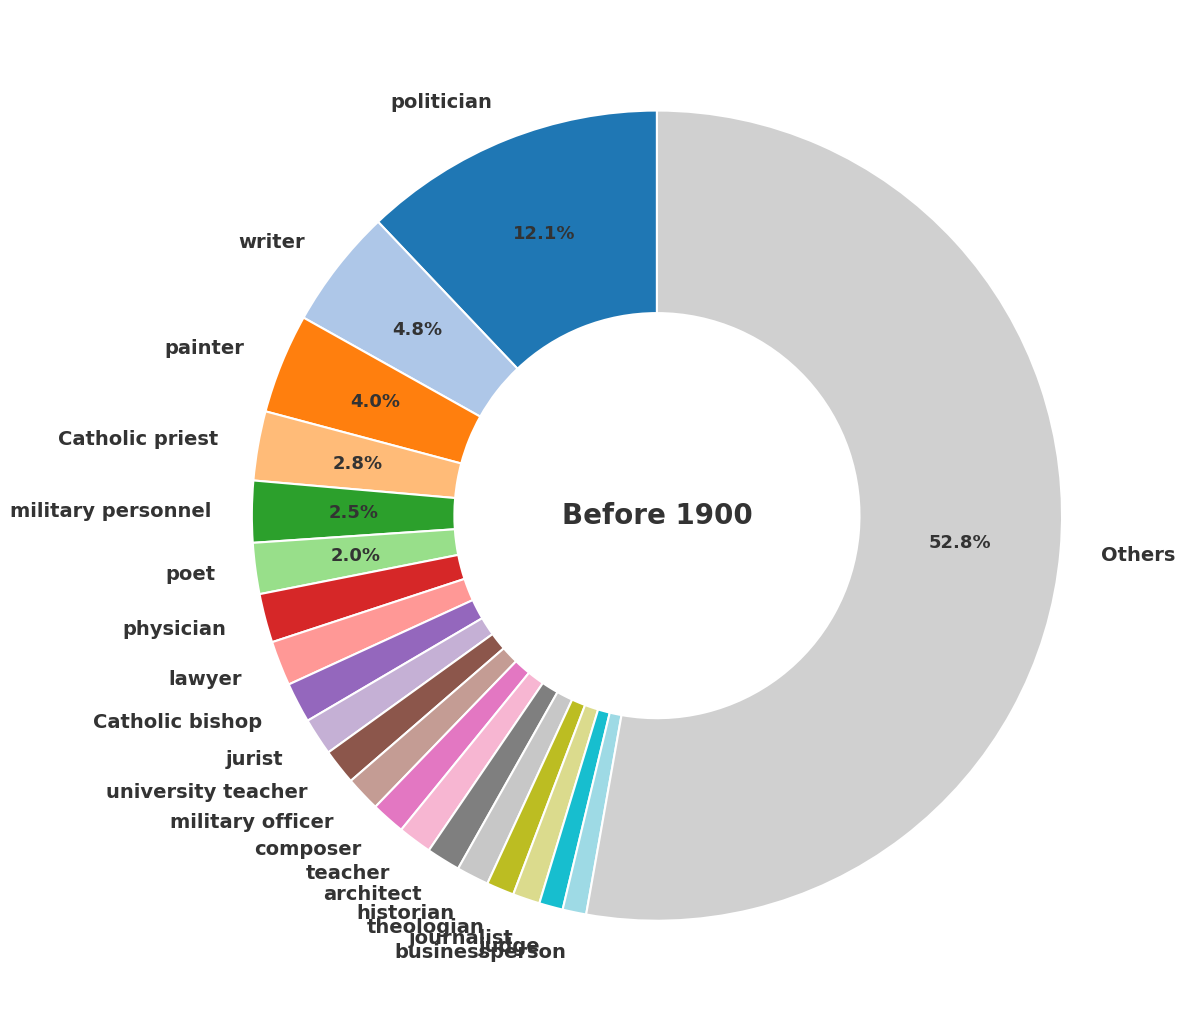

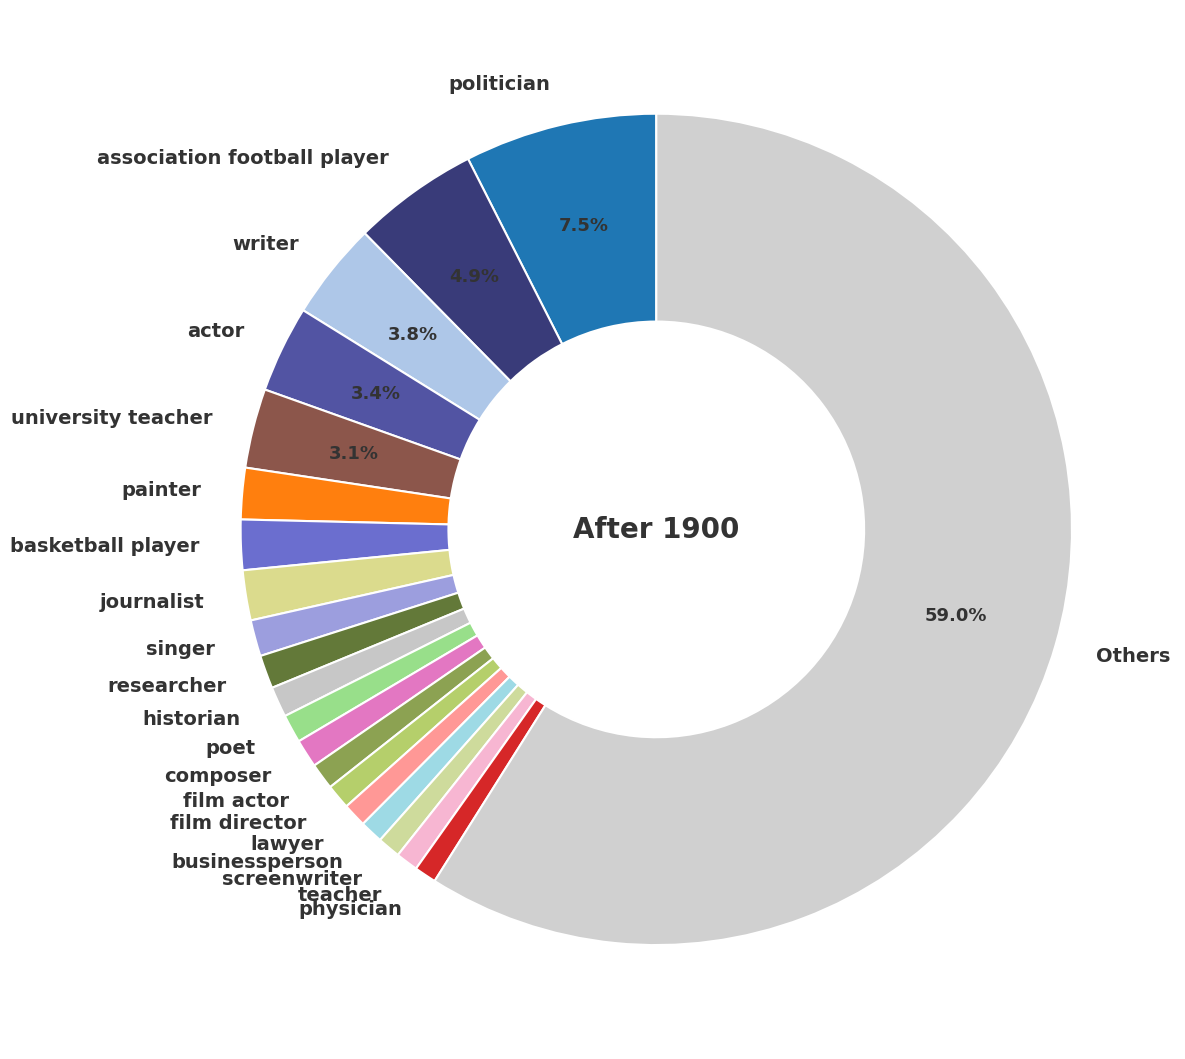

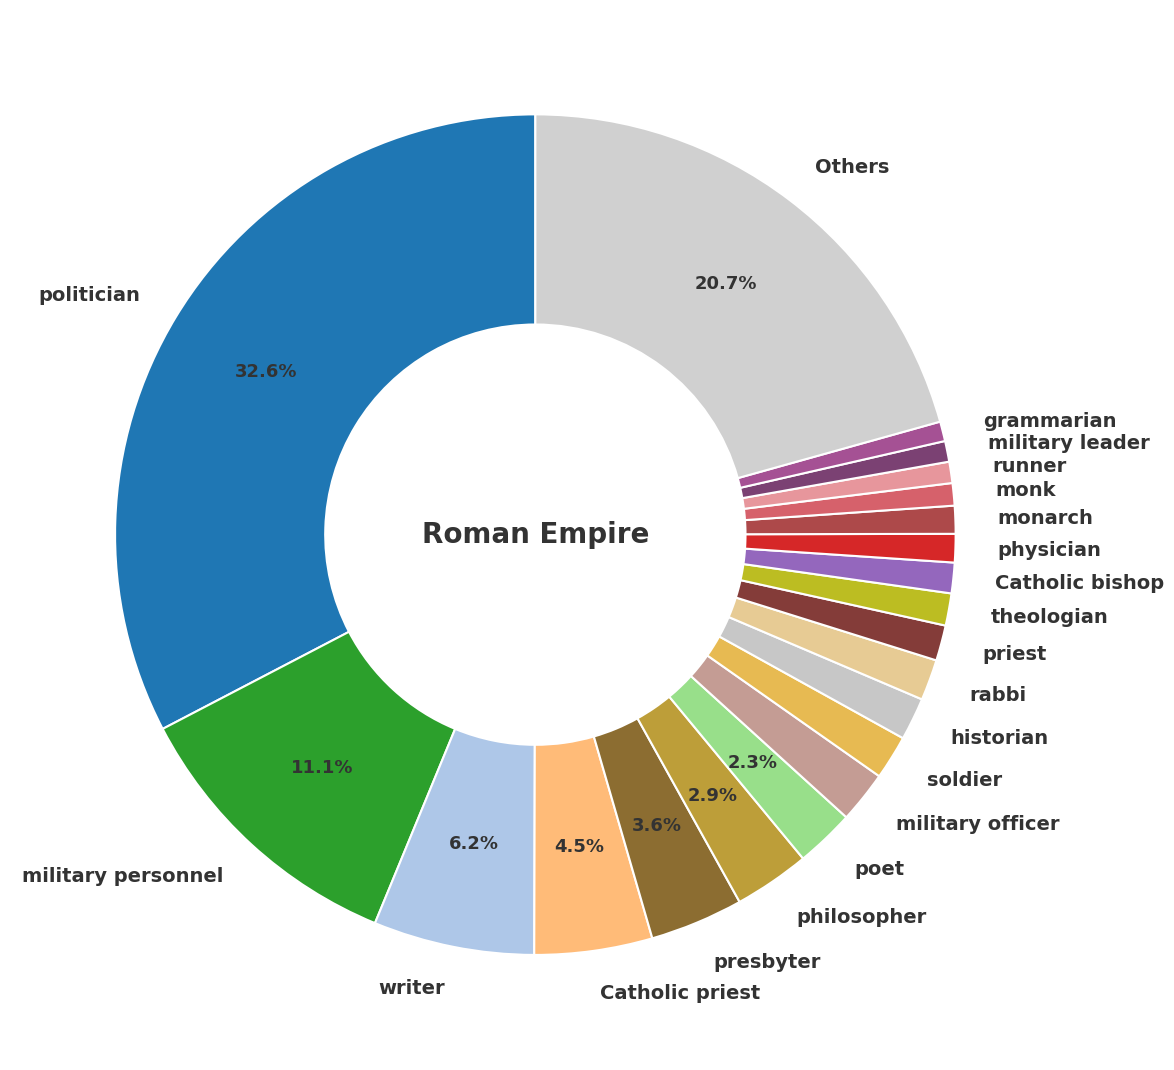

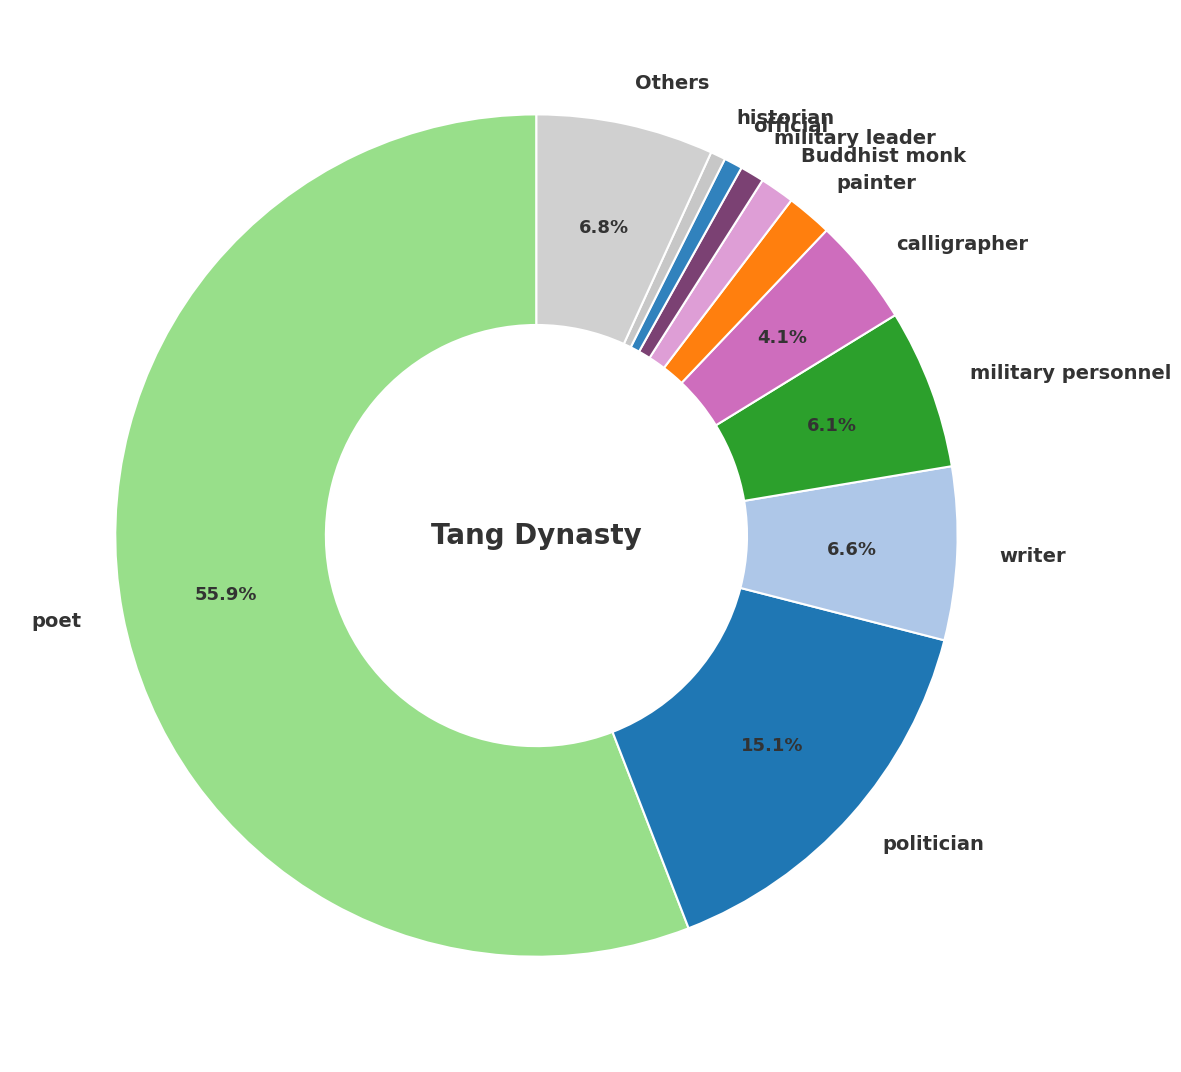

In [12]:
draw_donut(labels_before, sizes_before, 'Before 1900')
draw_donut(labels_after, sizes_after, 'After 1900')
draw_donut(labels_roman, sizes_roman, 'Roman Empire')
draw_donut(labels_tang, sizes_tang, 'Tang Dynasty')

## Donut chart -- Roman Empire

In [13]:
# Drawn above with all four charts
pass

## Donut chart -- Tang Dynasty

In [14]:
# Drawn above with all four charts
pass

## Clean up

In [15]:
conn.close()